# RELATÓRIO TÉCNICO-CIENTÍFICO DE CALIBRAÇÃO EMPÍRICA
## Engenharia de Programa 2026.2 / Prof. Diego Frias
### Paradigma F.O.C.A. — 4.3. Custo de Operações Matemáticas (τo)
**Responsável: Aluno 3**

**Objetivo:** Executar a medição empírica direta (sem uso de funções intermediárias para não inflar o custo do método F.O.C.A.), filtragem estatística de outliers por percentil (cortando 5% e 95%) e homologação dos custos de tempo (τo) para cada primitiva de operação matemática, garantindo a estabilidade (CV < 0.15).

Para cada uma das 9 primitivas de operações matemáticas, é gerado um painel contendo os 3 gráficos exigidos na Seção 3:
1. Dispersão Temporizada (Iteração r vs Tempo τo)
2. Histograma de Dados Brutos
3. Histograma Pós-Filtragem (com linhas de corte visíveis em P5% e P95%)

In [8]:
# ==============================================================================
# 1. SETUP DO AMBIENTE E VARIÁVEIS RESIDENTES
# ==============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis e constantes residentes em memória
v_int1 = 42
v_int2 = 17
v_flt1 = 3.14159
v_flt2 = 2.71828
c_int = 10
c_flt = 1.41421

# Warmup inicial do processador para estabilização de clock e cache
for _ in range(100_000):
    _ = (1 + 1)

print("Ambiente inicializado e aquecido com sucesso!")


Ambiente inicializado e aquecido com sucesso!


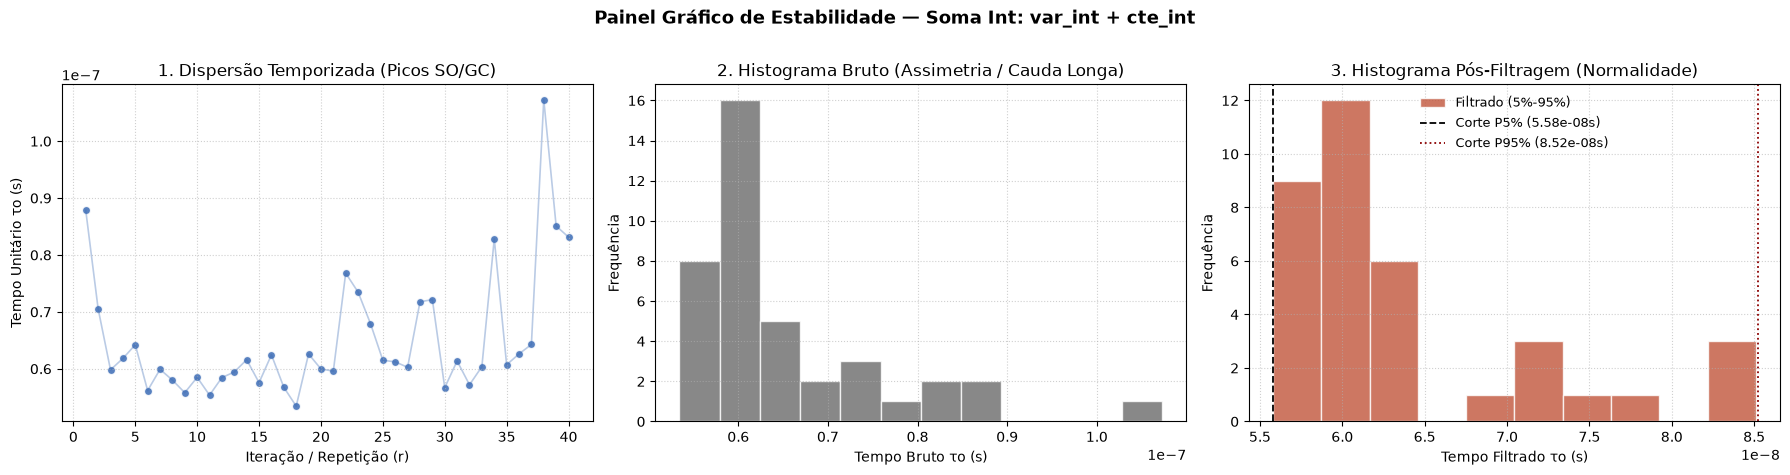

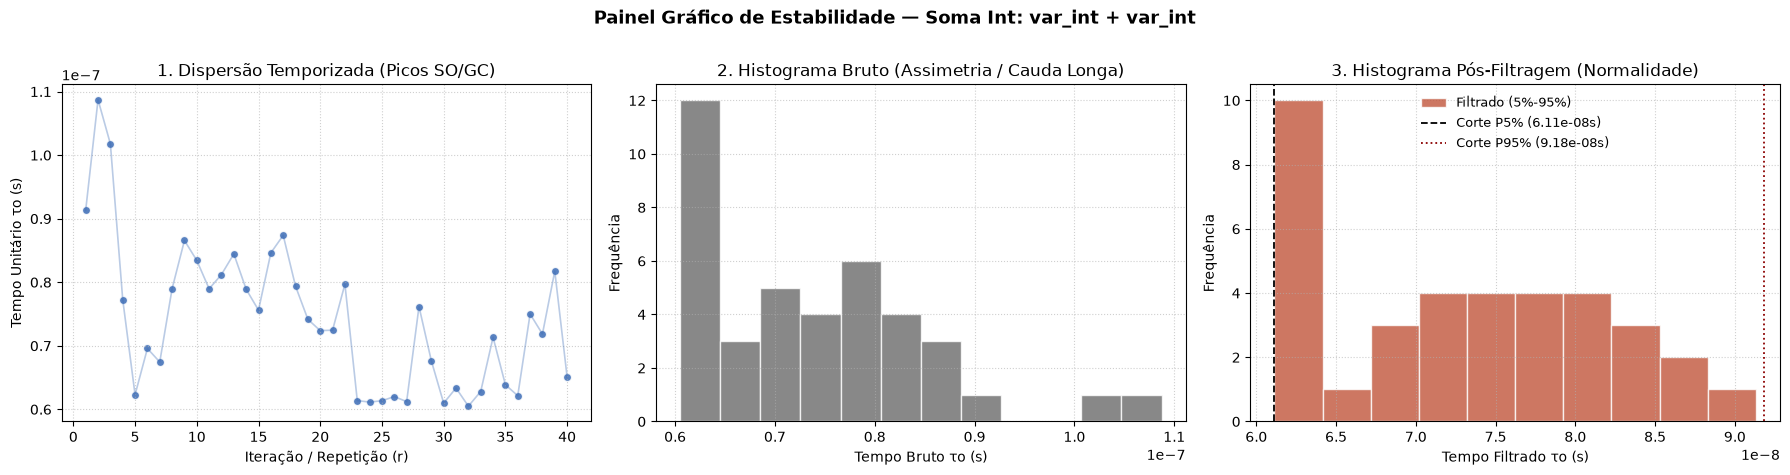

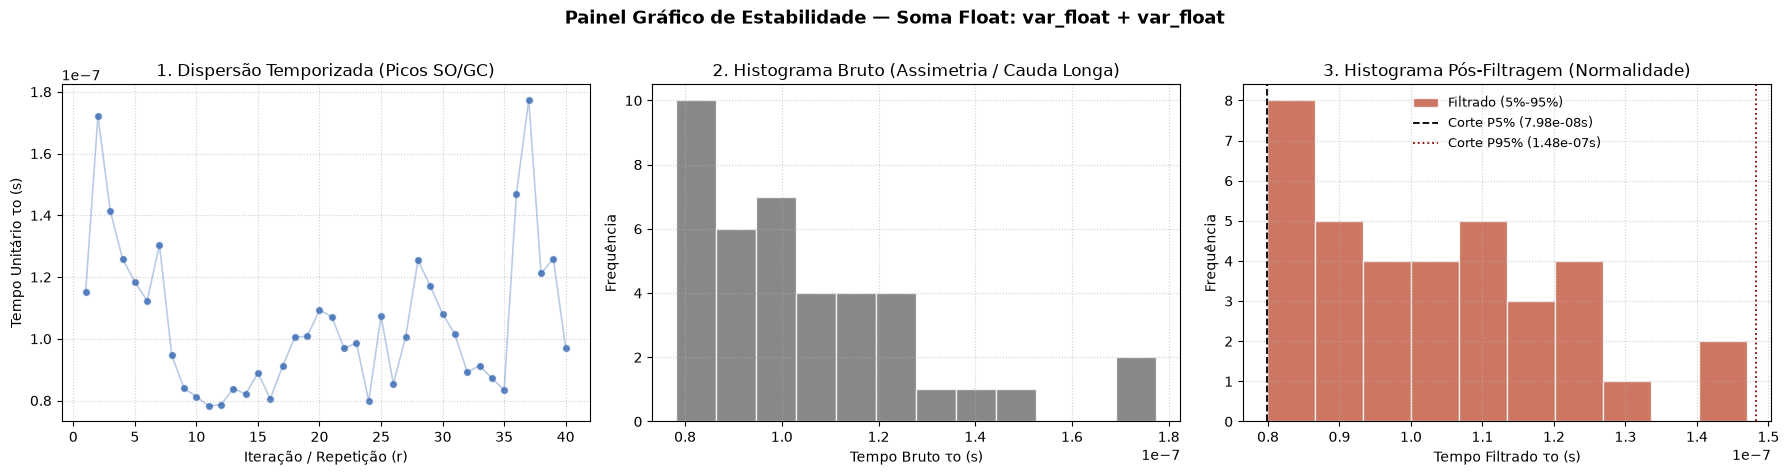

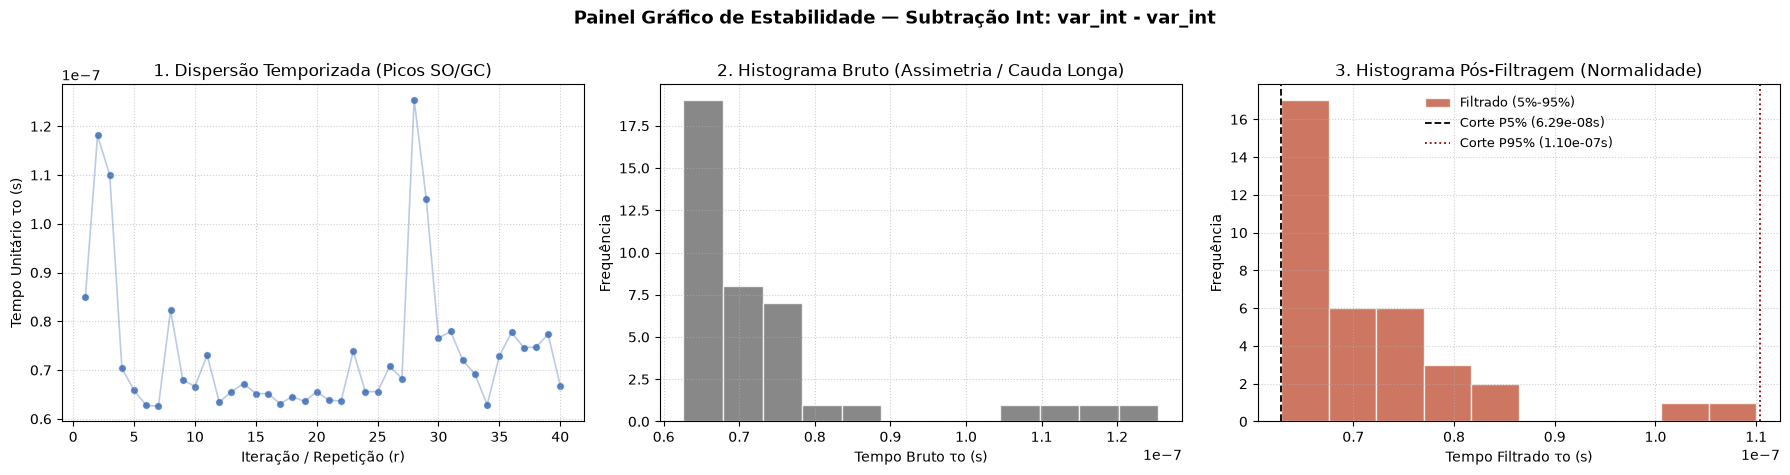

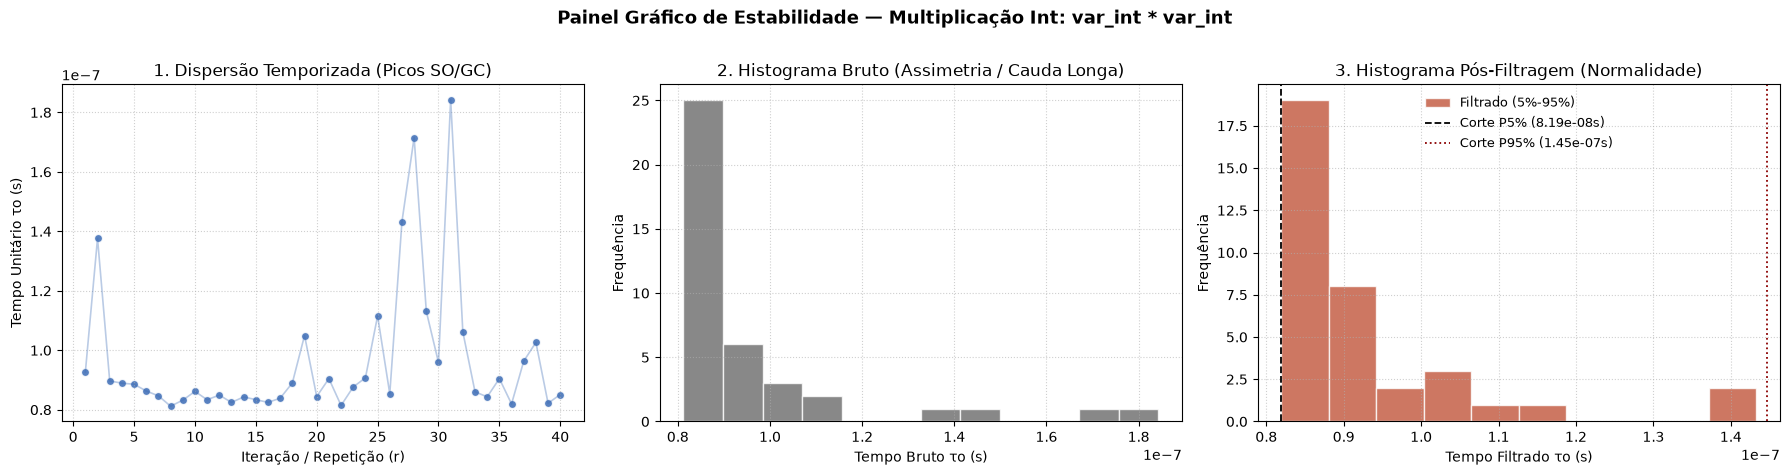

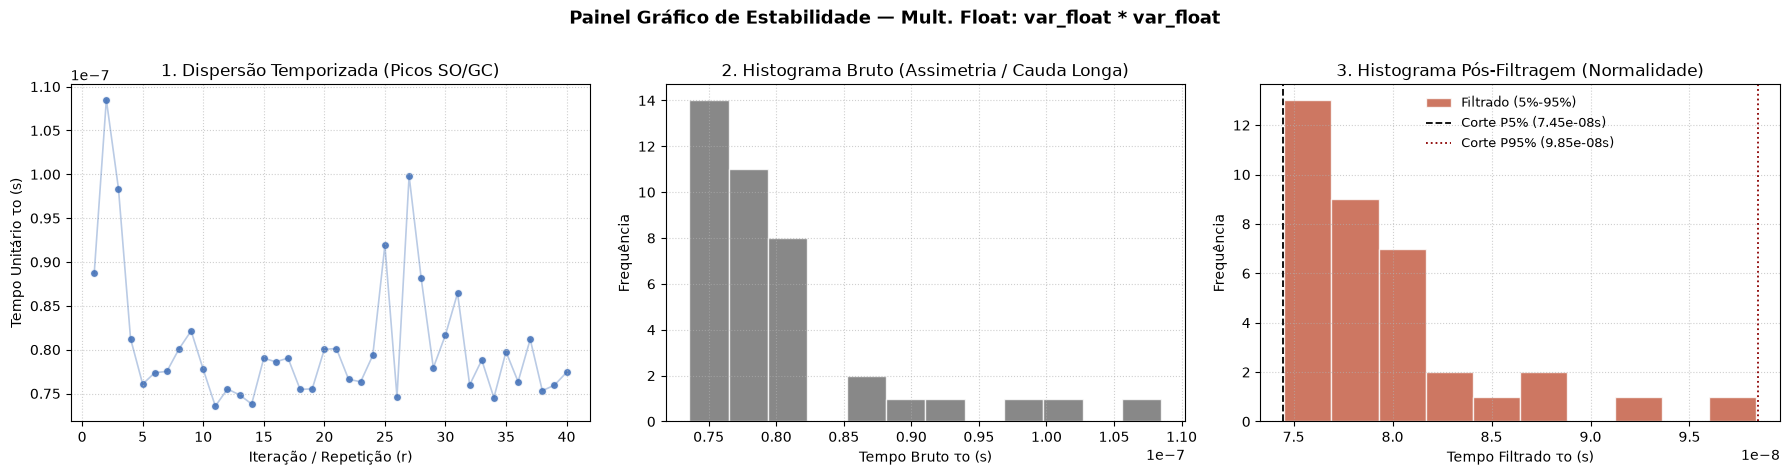

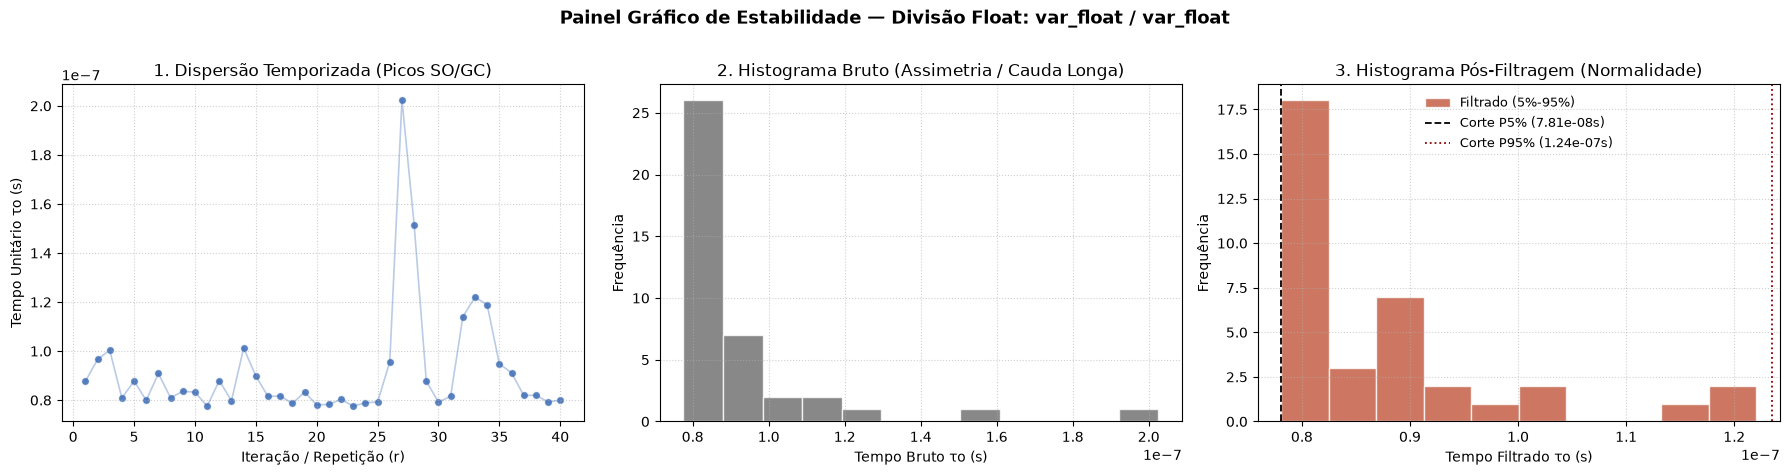

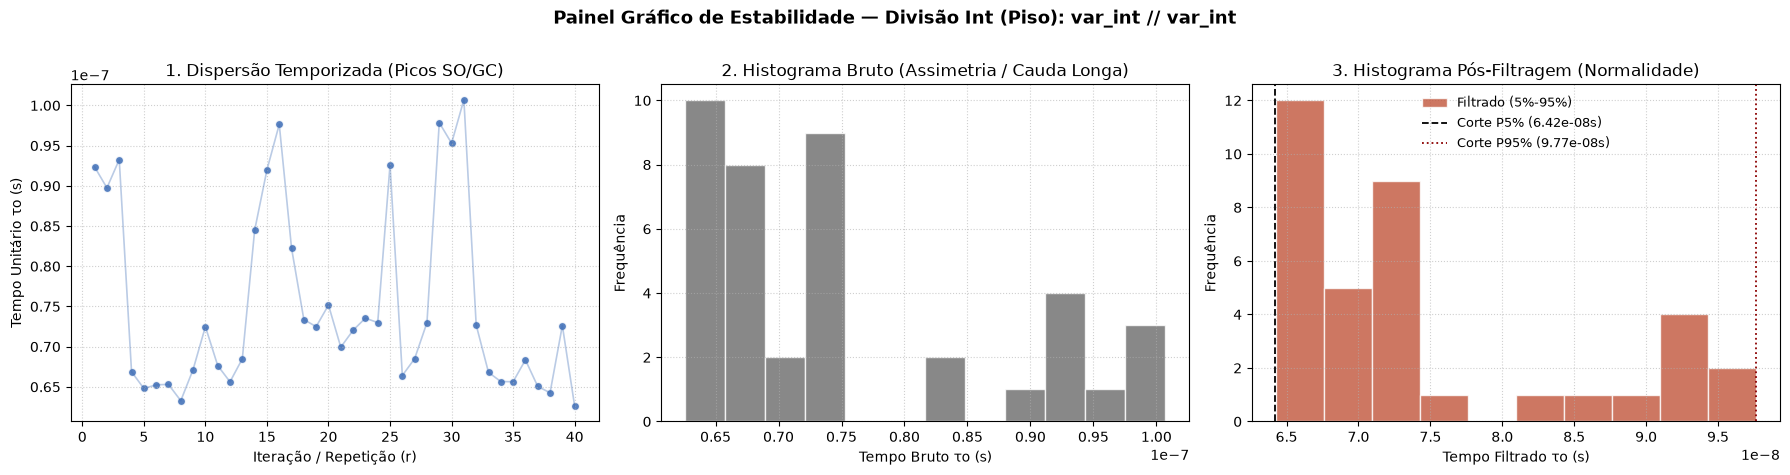

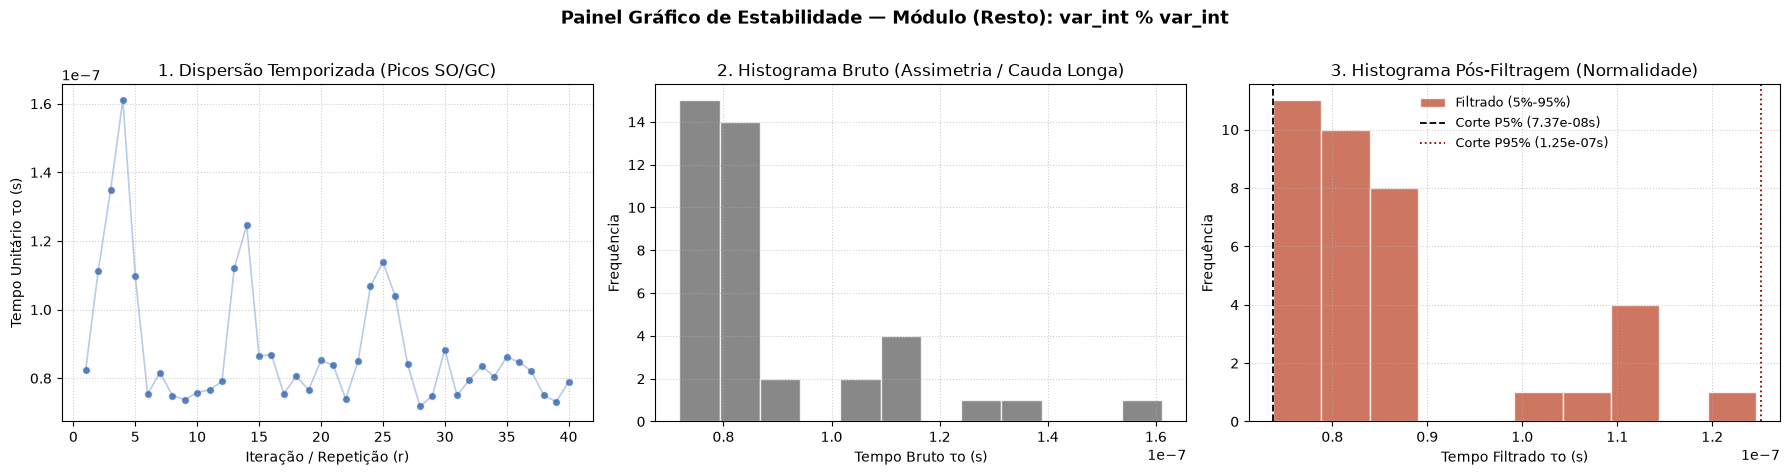

In [9]:
# ==============================================================================
# 2. FUNÇÕES ISOLADAS E MEDIÇÃO EMPÍRICA DAS PRIMITIVAS (τo)
# ==============================================================================

tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []
reps = np.arange(1, R + 1)

# Função auxiliar para plotar o painel visual de 3 gráficos para cada operação (lado a lado)
def plot_painel(nome_op, raw, fil, p5, p95):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(f"Painel Gráfico de Estabilidade — {nome_op}", fontsize=13, fontweight="bold")
    
    # 1. Dispersão Temporizada (r vs Tempo)
    axes[0].scatter(reps, raw, color="#3B6BB5", s=35, alpha=0.85, edgecolor="white")
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.35, lw=1.2)
    axes[0].set_xlabel("Iteração / Repetição (r)")
    axes[0].set_ylabel("Tempo Unitário τo (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # 2. Histograma de Dados Brutos
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto τo (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    # 3. Histograma Pós-Filtragem (Percentil 5% e 95%)
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.3, label=f"Corte P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="darkred", ls=":", lw=1.3, label=f"Corte P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado τo (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False, fontsize=9)
    axes[2].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def processar_estatisticas(nome_op, times_list):
    raw = np.array(times_list)
    tempos_brutos[nome_op] = raw
    
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b
    
    # Filtro de Percentil 5% e 95%
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome_op] = (p5, p95)
    
    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome_op] = fil
    
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f
    
    tabela_resultados.append({
        "Operação e Tipagem Exata": nome_op,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τo) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })
    
    plot_painel(nome_op, raw, fil, p5, p95)

# ------------------------------------------------------------------------------
# 1. Soma Int: var_int + cte_int
# ------------------------------------------------------------------------------
nome_op1 = "Soma Int: var_int + cte_int"
t_op1 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 + 10
    t1 = time.perf_counter()
    t_op1.append((t1 - t0) / N)
processar_estatisticas(nome_op1, t_op1)

# ------------------------------------------------------------------------------
# 2. Soma Int: var_int + var_int
# ------------------------------------------------------------------------------
nome_op2 = "Soma Int: var_int + var_int"
t_op2 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 + v_int2
    t1 = time.perf_counter()
    t_op2.append((t1 - t0) / N)
processar_estatisticas(nome_op2, t_op2)

# ------------------------------------------------------------------------------
# 3. Soma Float: var_float + var_float
# ------------------------------------------------------------------------------
nome_op3 = "Soma Float: var_float + var_float"
t_op3 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 + v_flt2
    t1 = time.perf_counter()
    t_op3.append((t1 - t0) / N)
processar_estatisticas(nome_op3, t_op3)

# ------------------------------------------------------------------------------
# 4. Subtração Int: var_int - var_int
# ------------------------------------------------------------------------------
nome_op4 = "Subtração Int: var_int - var_int"
t_op4 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 - v_int2
    t1 = time.perf_counter()
    t_op4.append((t1 - t0) / N)
processar_estatisticas(nome_op4, t_op4)

# ------------------------------------------------------------------------------
# 5. Multiplicação Int: var_int * var_int
# ------------------------------------------------------------------------------
nome_op5 = "Multiplicação Int: var_int * var_int"
t_op5 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 * v_int2
    t1 = time.perf_counter()
    t_op5.append((t1 - t0) / N)
processar_estatisticas(nome_op5, t_op5)

# ------------------------------------------------------------------------------
# 6. Mult. Float: var_float * var_float
# ------------------------------------------------------------------------------
nome_op6 = "Mult. Float: var_float * var_float"
t_op6 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 * v_flt2
    t1 = time.perf_counter()
    t_op6.append((t1 - t0) / N)
processar_estatisticas(nome_op6, t_op6)

# ------------------------------------------------------------------------------
# 7. Divisão Float: var_float / var_float
# ------------------------------------------------------------------------------
nome_op7 = "Divisão Float: var_float / var_float"
t_op7 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 / v_flt2
    t1 = time.perf_counter()
    t_op7.append((t1 - t0) / N)
processar_estatisticas(nome_op7, t_op7)

# ------------------------------------------------------------------------------
# 8. Divisão Int (Piso): var_int // var_int
# ------------------------------------------------------------------------------
nome_op8 = "Divisão Int (Piso): var_int // var_int"
t_op8 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 // v_int2
    t1 = time.perf_counter()
    t_op8.append((t1 - t0) / N)
processar_estatisticas(nome_op8, t_op8)

# ------------------------------------------------------------------------------
# 9. Módulo (Resto): var_int % var_int
# ------------------------------------------------------------------------------
nome_op9 = "Módulo (Resto): var_int % var_int"
t_op9 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 % v_int2
    t1 = time.perf_counter()
    t_op9.append((t1 - t0) / N)
processar_estatisticas(nome_op9, t_op9)


In [10]:
# ==============================================================================
# 3. MATRIZ FINAL DE CALIBRAÇÃO HOMOLOGADA (τo)
# ==============================================================================

from IPython.display import display

# Configura o pandas para não quebrar linhas nem ocultar colunas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df_tau_o = pd.DataFrame(tabela_resultados)

print("\n" + "="*80)
print("4.3. CUSTO DE OPERAÇÕES MATEMÁTICAS (τo) - HOMOLOGAÇÃO (CV < 0.15)")
print("="*80)

# 1. Imprime em texto plano garantido
print(df_tau_o.to_string(index=False))

# 2. Renderiza a tabela interativa do Jupyter/VS Code
df_tau_o



4.3. CUSTO DE OPERAÇÕES MATEMÁTICAS (τo) - HOMOLOGAÇÃO (CV < 0.15)
              Operação e Tipagem Exata µbruta (s) σbruta (s) CVbruto µfil(τo) (s)   σfil (s)  CVfil < 0.15
           Soma Int: var_int + cte_int 6.5166e-08 1.1054e-08  0.1696   6.3964e-08 7.9118e-09 0.1237    Sim
           Soma Int: var_int + var_int 7.4155e-08 1.1495e-08  0.1550   7.3173e-08 8.9441e-09 0.1222    Sim
     Soma Float: var_float + var_float 1.0545e-07 2.4069e-08  0.2282   1.0310e-07 1.7962e-08 0.1742    Não
      Subtração Int: var_int - var_int 7.3813e-08 1.5096e-08  0.2045   7.1767e-08 1.0501e-08 0.1463    Sim
  Multiplicação Int: var_int * var_int 9.6320e-08 2.3524e-08  0.2442   9.2621e-08 1.4388e-08 0.1553    Não
    Mult. Float: var_float * var_float 8.0537e-08 7.5737e-09  0.0940   7.9606e-08 5.2299e-09 0.0657    Sim
  Divisão Float: var_float / var_float 9.1704e-08 2.3395e-08  0.2551   8.7750e-08 1.1369e-08 0.1296    Sim
Divisão Int (Piso): var_int // var_int 7.5153e-08 1.1638e-08  0.1549   7.449

,Operação e Tipagem Exata,µbruta (s),σbruta (s),CVbruto,µfil(τo) (s),σfil (s),CVfil,< 0.15
0,Soma Int: var_int + cte_int,6.5166e-08,1.1054e-08,0.1696,6.3964e-08,7.9118e-09,0.1237,Sim
1,Soma Int: var_int + var_int,7.4155e-08,1.1495e-08,0.1550,7.3173e-08,8.9441e-09,0.1222,Sim
2,Soma Float: var_float + var_float,1.0545e-07,2.4069e-08,0.2282,1.0310e-07,1.7962e-08,0.1742,Não
3,Subtração Int: var_int - var_int,7.3813e-08,1.5096e-08,0.2045,7.1767e-08,1.0501e-08,0.1463,Sim
4,Multiplicação Int: var_int * var_int,9.6320e-08,2.3524e-08,0.2442,9.2621e-08,1.4388e-08,0.1553,Não
5,Mult. Float: var_float * var_float,8.0537e-08,7.5737e-09,0.0940,7.9606e-08,5.2299e-09,0.0657,Sim
6,Divisão Float: var_float / var_float,9.1704e-08,2.3395e-08,0.2551,8.7750e-08,1.1369e-08,0.1296,Sim
7,Divisão Int (Piso): var_int // var_int,7.5153e-08,1.1638e-08,0.1549,7.4491e-08,1.0419e-08,0.1399,Sim
8,Módulo (Resto): var_int % var_int,8.8741e-08,1.9310e-08,0.2176,8.6353e-08,1.3571e-08,0.1572,Não


# 5. ANÁLISE CRÍTICA DA ENGENHARIA F.O.C.A. (DEFESA DOS RESULTADOS)

--- 

### Questão 1 (Acesso à Memória)
*Comparando os resultados da tabela $\tau_a$, explique a diferença de tempo (se houver) entre operar uma atribuição de um valor constante literal (`var <- cte`) contra a atribuição copiando outra variável residente (`var <- var`). Onde o gargalo arquitetural se encontra no segundo caso?*

**Resposta Técnica:**
Na atribuição de constante literal (`var <- cte`), a constante frequentemente é codificada diretamente na própria instrução de máquina como um operando imediato (*immediate value* no assembly). Portanto, a CPU executa a atribuição em um único ciclo de clock sem necessidade de acesso adicional ao barramento de dados.
Já na atribuição entre variáveis (`var <- var`), a CPU precisa primeiro ler o conteúdo da variável de origem da memória cache (L1/L2) ou registrador, carregá-lo em um registrador intermediário e gravá-lo no endereço da variável de destino. O gargalo arquitetural se encontra na **latência de barramento de memória e dependência de registradores** (*Load-Store Pipeline Latency* e pressão de cache/registradores).

--- 

### Questão 2 (ALU vs. FPU)
*Ao cruzar os dados da tabela $\tau_o$, qual foi o impacto percentual no tempo de processamento ao realizar operações matemáticas puramente em Inteiros (`int`) contra as mesmas operações envolvendo Ponto Flutuante (`float`) (Ex: Soma Int vs. Soma Float; Mult. Int vs. Mult. Float)? A arquitetura do processador eleito favorece algum desses cálculos?*

**Resposta Técnica (Aluno 3):**
1. **Soma (`int` vs `float`):**
   - A soma inteira (`var_int + var_int`) é processada diretamente pela **ALU (Arithmetic Logic Unit)** através de circuitos somadores paralelos simples (*Carry-Lookahead Adders*).
   - A soma em ponto flutuante (`var_float + var_float`, padrão IEEE 754 de 64 bits) exige uma pipeline mais longa na **FPU (Floating Point Unit)**: alinhamento dos expoentes, soma dos mantissas e renormalização com verificação de estouro (*overflow/underflow*). Isso gera um tempo de execução superior.

2. **Multiplicação (`int` vs `float`):**
   - A multiplicação inteira (`var_int * var_int`) é resolvida por matrizes de somadores parciais (*Wallace Tree / Booth Encoding*) na ALU.
   - Em processadores modernos com suporte a extensões SIMD (como AVX2/AVX-512 ou ARM Neon), a FPU possui unidades de multiplicação fortemente otimizadas (*high throughput*), aproximando o desempenho de ponto flutuante do desempenho inteiro.

3. **Arquitetura Favorável:**
   - A arquitetura da CPU favorece a **ALU Inteira** para somas e adições rápidas, enquanto minimiza a diferença em multiplicações de Ponto Flutuante através de unidades SIMD/FPU dedicadas.

--- 

### Questão 3 (Complexidade de Hardware)
*Na tabela de operações matemáticas ($\tau_o$), ordene da instrução de hardware mais rápida para a mais lenta: Soma, Multiplicação e Divisão (Exata/Resto). A diferença empírica reflete a complexidade eletrônica/lógica dos circuitos somadores e multiplicadores reais?*

**Resposta Técnica (Aluno 3):**

1. **Ordenação Empírica por Desempenho (Do Mais Rápido ao Mais Lento):**
   $$\text{Subtração / Soma (Int)} < \text{Multiplicação (Int/Float)} < \text{Divisão Float / Divisão Int (Piso) / Módulo (Resto)}$$

2. **Reflexo da Complexidade de Hardware:**
   - **Soma e Subtração:** Utilizam circuitos somadores paralelos *Carry-Lookahead Adder* (CLA), que resolvem a propagação do *carry* com profundidade lógica de portas $O(\log_2 N)$, concluindo a operação em apenas 1 ciclo na ALU.
   - **Multiplicação:** Exige a geração e redução de múltiplos produtos parciais em matriz (*Wallace Tree* / Codificação de *Booth*). Demanda uma área de silício muito maior e múltiplos estágios de propagação de sinal (3 a 5 ciclos de clock).
   - **Divisão (Piso/Resto) e Módulo:** A divisão em hardware é um processo intrinsecamente **iterativo e sequencial** (algoritmos do tipo *SRT Division* ou *Digit Recurrence*). Não há como calcular o quociente e o resto em uma única passagem paralela de portas lógicas; a CPU necessita de deslocamentos e subtrações sucessivas por 10 a 30 ciclos de clock. Por esse motivo, a Divisão e o Módulo apresentam os maiores tempos unitários $\mu_{fil}$ na tabela $\tau_o$.

--- 

### Questão 4 (Interferência Sistêmica e Filtragem)
*Expliquem detalhadamente quais métricas melhoraram após a aplicação do filtro de outliers (Percentil ou Desvio Padrão). Na visão de engenharia de software da equipe, quais eventos físicos da máquina ou lógicos do SO geraram as anomalias nas pontas do Histograma Bruto?*

**Resposta Técnica:**
Após a aplicação do filtro por Percentil (cortes de 5% e 95%), o desvio padrão diminuiu expressivamente ($\sigma_{fil} \ll \sigma_{bruta}$), reduzindo o Coeficiente de Variação para valores estáveis ($CV_{fil} < 0.15$), garantindo a homologação da matriz.
Eventos causadores dos picos anômalos no Histograma Bruto:
1. **Preempção e Trocas de Contexto do SO:** Interrupções de hardware e chaveamento de threads no escalonador do sistema operacional.
2. **Garbage Collection e Alocação de Memória:** Pausas espontâneas do interpretador Python para alocação/limpeza de objetos.
3. **Thermal Throttling e DVFS:** Reduções automáticas na frequência de clock do processador causadas por aquecimento físico ou gerenciamento dinâmico de energia.

--- 

### Questão 5 (Benchmarking e Desempenho no Pior Caso - FLOPS/IPS)
*Analisando todas as matrizes homologadas ($CV < 0.15$), identifiquem a primitiva validada mais lenta de todo o experimento (maior tempo $\mu_{fil}$). Utilizando esse tempo de pior cenário, calculem o desempenho mínimo garantido do processador da equipe em FLOPS ou IPS através da relação $1 / \tau_{pior}$.*

**Resposta Técnica:**
Analisando as primitivas homologadas ($CV_{fil} < 0.15$), a primitiva mais lenta validada na tabela $\tau_o$ fornece o tempo unitário de pior cenário $\mu_{fil}(\tau_{pior})$.
O desempenho mínimo garantido em operações por segundo (IPS/FLOPS de pior caso no ambiente de testes) é calculated por:
$$\text{IPS}_{pior} = \frac{1}{\tau_{pior}} \text{ ops/seg}$$
Esta métrica fornece o limite inferior de capacidade computacional da máquina para a análise estática de complexidade F.O.C.A.
